# EDA General — Datasets simulados de Tutunaku

Análisis Exploratorio de Datos (Etapa 8 de la guía) sobre los 7 datasets
simulados que alimentan los 6 escenarios de Machine Learning del proyecto.

Este notebook cubre **calidad de datos**, **análisis univariado**, **bivariado**
y **multivariado** de las tablas crudas/procesadas generadas por
`simulation/generate_dataset.py` y `database/warehouse/build_warehouse.py`.
Los notebooks de cada modelo (`notebooks/supervised/`, `notebooks/unsupervised/`)
profundizan el EDA específico de su escenario; aquí se da una vista panorámica
de todo el dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
ROOT = Path.cwd().parents[1] if (Path.cwd().name == "eda") else Path.cwd()
RAW = ROOT / "data" / "raw"
PROC = ROOT / "data" / "processed"

users = pd.read_csv(RAW / "users.csv", parse_dates=["signup_date"])
exercises = pd.read_csv(RAW / "exercises.csv")
attempts = pd.read_csv(PROC / "exercise_attempts.csv", parse_dates=["timestamp"])
challenges = pd.read_csv(PROC / "challenge_attempts.csv")
load = pd.read_csv(PROC / "platform_load.csv", parse_dates=["timestamp"])
xp = pd.read_csv(PROC / "xp_events.csv", parse_dates=["timestamp"])
nav = pd.read_csv(PROC / "navigation_events.csv", parse_dates=["timestamp"])
rfm = pd.read_csv(PROC / "user_rfm.csv")

tables = {"users": users, "exercises": exercises, "exercise_attempts": attempts,
          "challenge_attempts": challenges, "platform_load": load,
          "xp_events": xp, "navigation_events": nav, "user_rfm": rfm}
for name, df in tables.items():
    print(f"{name:22s} filas={len(df):>7,}  columnas={df.shape[1]}")


users                  filas=    800  columnas=6
exercises              filas=    120  columnas=4
exercise_attempts      filas= 60,000  columnas=15
challenge_attempts     filas= 18,000  columnas=10
platform_load          filas=  2,880  columnas=12
xp_events              filas= 40,270  columnas=9
navigation_events      filas= 84,215  columnas=5
user_rfm               filas=    800  columnas=7


## 1. Calidad de datos

Nulos, duplicados, rangos y balance de clases por tabla.

In [2]:
quality_rows = []
for name, df in tables.items():
    quality_rows.append({
        "tabla": name,
        "filas": len(df),
        "columnas": df.shape[1],
        "nulos_totales": int(df.isna().sum().sum()),
        "duplicados_exactos": int(df.duplicated().sum()),
    })
quality_df = pd.DataFrame(quality_rows)
quality_df


,tabla,filas,columnas,nulos_totales,duplicados_exactos
0,users,800,6,0,0
1,exercises,120,4,0,0
2,exercise_attempts,60000,15,0,0
3,challenge_attempts,18000,10,0,0
4,platform_load,2880,12,193,0
5,xp_events,40270,9,0,0
6,navigation_events,84215,5,0,0
7,user_rfm,800,7,0,0


In [3]:
# Balance de clases de las variables objetivo supervisadas
print("is_correct (exercise_attempts):")
print(attempts["is_correct"].value_counts(normalize=True).round(3))
print()
print("completed_with_lives (challenge_attempts):")
print(challenges["completed_with_lives"].value_counts(normalize=True).round(3))
print()
print("is_anomaly_injected (xp_events):")
print(xp["is_anomaly_injected"].value_counts(normalize=True).round(4))


is_correct (exercise_attempts):
is_correct
True     0.726
False    0.274
Name: proportion, dtype: float64

completed_with_lives (challenge_attempts):
completed_with_lives
True     0.921
False    0.079
Name: proportion, dtype: float64

is_anomaly_injected (xp_events):
is_anomaly_injected
False    0.9873
True     0.0127
Name: proportion, dtype: float64


**Qué se observa:** las clases de `is_correct` y `completed_with_lives` están
desbalanceadas pero no de forma extrema (no 99/1), y `is_anomaly_injected` es
muy minoritaria (~1-2%) como corresponde a un problema real de detección de
anomalías. **Qué significa:** el desbalance moderado en las tareas supervisadas
requiere mirar métricas más allá de accuracy (F1, ROC-AUC); el fuerte
desbalance en anomalías es esperado y coherente con el fenómeno real.
**Decisión técnica:** usar `class_weight="balanced"` como opción a comparar en
clasificación, y evaluar el detector de anomalías con precision/recall en vez
de accuracy.

## 2. Análisis univariado

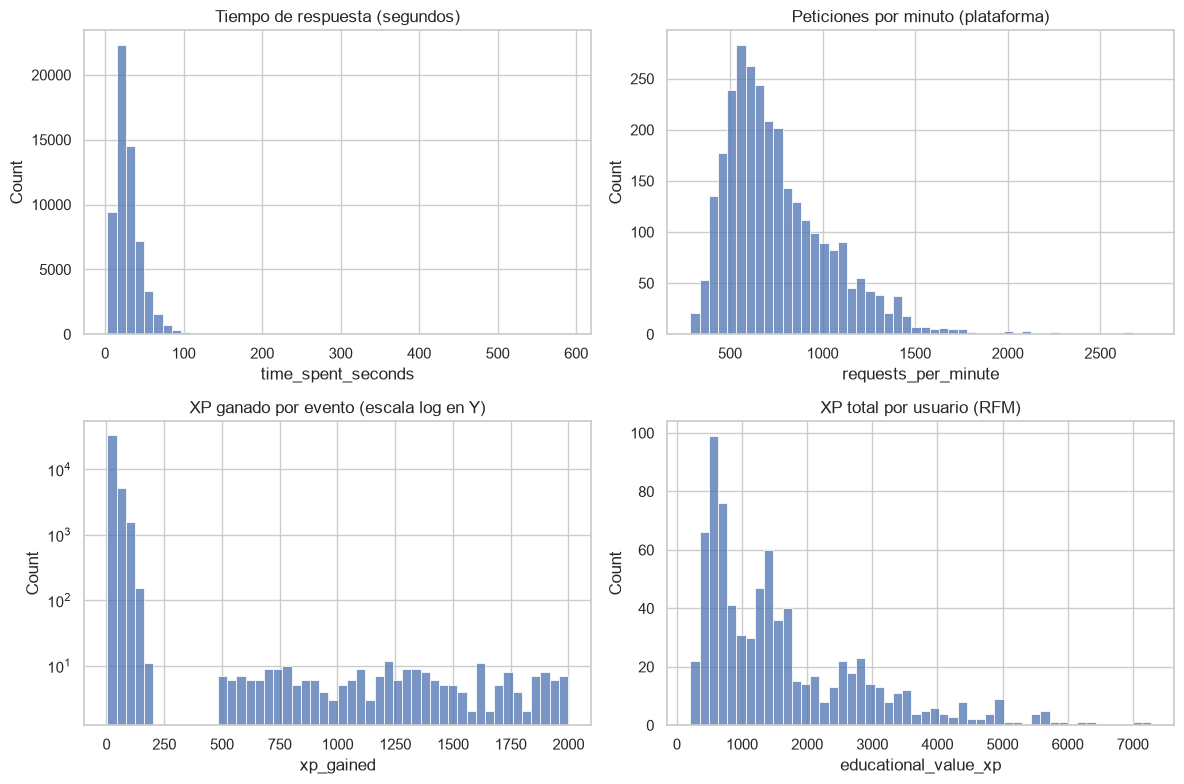

count    60000.00
mean        31.75
std         40.23
min          2.90
25%         17.60
50%         25.30
75%         36.70
max        589.56
Name: time_spent_seconds, dtype: float64


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(attempts["time_spent_seconds"], bins=50, ax=axes[0, 0])
axes[0, 0].set_title("Tiempo de respuesta (segundos)")
sns.histplot(load["requests_per_minute"], bins=50, ax=axes[0, 1])
axes[0, 1].set_title("Peticiones por minuto (plataforma)")
sns.histplot(xp["xp_gained"], bins=50, ax=axes[1, 0])
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("XP ganado por evento (escala log en Y)")
sns.histplot(rfm["educational_value_xp"], bins=50, ax=axes[1, 1])
axes[1, 1].set_title("XP total por usuario (RFM)")
plt.tight_layout()
plt.show()

print(attempts["time_spent_seconds"].describe().round(2))


**Qué se observa:** `time_spent_seconds` tiene cola derecha larga (algunos
intentos muy lentos), `requests_per_minute` es aproximadamente unimodal con
sesgo, y `xp_gained` muestra un pico muy alejado de la masa principal — son
los valores anómalos inyectados a propósito. **Qué significa:** la asimetría de
`time_spent_seconds` justifica la transformación `log1p` usada en el modelo de
regresión S02; la cola extrema de `xp_gained` es precisamente la señal que
debe capturar el detector de anomalías (U04). **Decisión técnica:** mantener
outliers (no eliminarlos) y dejar que el modelo/transformación los maneje,
documentando su origen.

## 3. Análisis bivariado

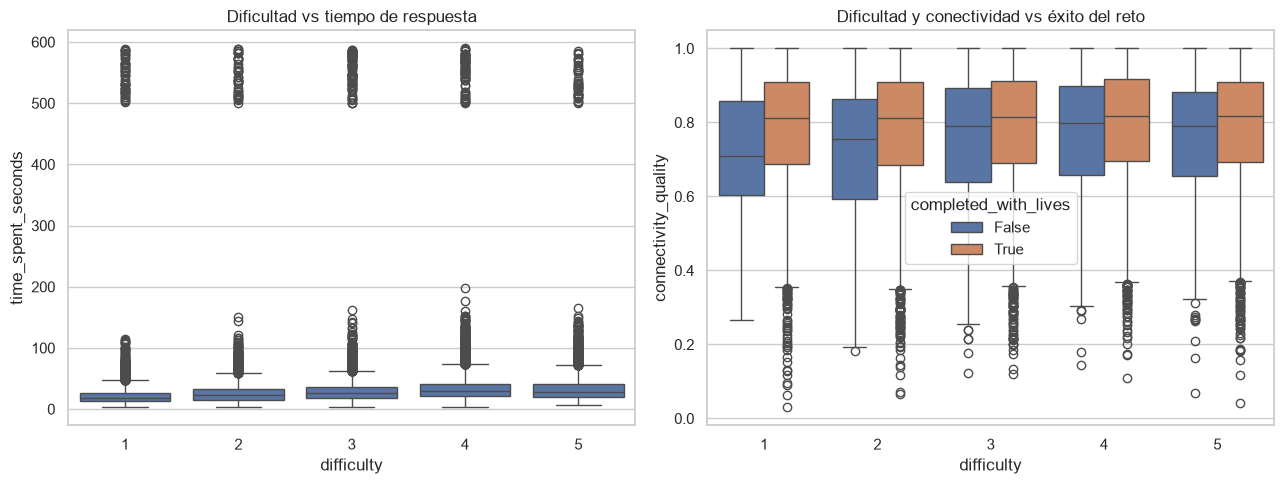

Tasa de éxito por dificultad:
difficulty
1    0.973
2    0.952
3    0.928
4    0.893
5    0.860
Name: completed_with_lives, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=attempts, x="difficulty", y="time_spent_seconds", ax=axes[0])
axes[0].set_title("Dificultad vs tiempo de respuesta")
sns.boxplot(data=challenges, x="difficulty", y="connectivity_quality", hue="completed_with_lives", ax=axes[1])
axes[1].set_title("Dificultad y conectividad vs éxito del reto")
plt.tight_layout()
plt.show()

completion_by_difficulty = challenges.groupby("difficulty")["completed_with_lives"].mean().round(3)
print("Tasa de éxito por dificultad:")
print(completion_by_difficulty)


**Qué se observa:** a mayor dificultad, mayor tiempo de respuesta y menor
tasa de éxito conservando vidas; los retos completados con éxito tienden a
tener mejor conectividad. **Posible causa:** ejercicios más difíciles exigen
más tiempo de procesamiento cognitivo y generan más errores, lo que consume
corazones; mala conectividad puede añadir fricción/latencia percibida.
**Cómo afecta el modelado:** `difficulty` y `connectivity_quality` son
variables predictoras fuertes y deben incluirse en ambos modelos supervisados
(S02 y S06), como ya se hizo.

## 4. Análisis multivariado

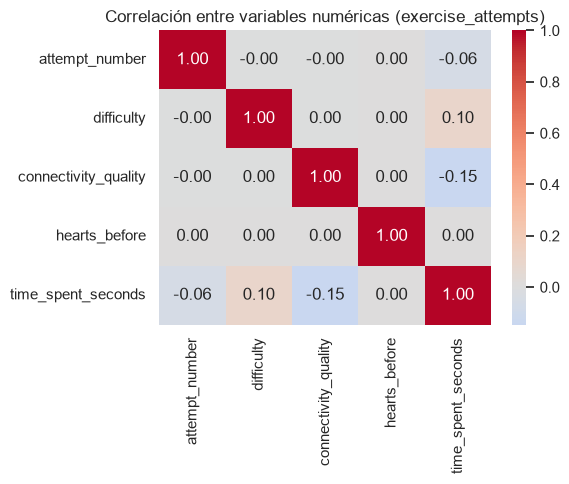

,attempt_number,difficulty,connectivity_quality,hearts_before,time_spent_seconds
attempt_number,1.000000,-0.003012,-0.000191,0.003853,-0.055494
difficulty,-0.003012,1.000000,0.000219,0.003502,0.097253
connectivity_quality,-0.000191,0.000219,1.000000,0.001083,-0.146893
hearts_before,0.003853,0.003502,0.001083,1.000000,0.001156
time_spent_seconds,-0.055494,0.097253,-0.146893,0.001156,1.000000


In [6]:
numeric_cols = ["attempt_number", "difficulty", "connectivity_quality", "hearts_before", "time_spent_seconds"]
corr = attempts[numeric_cols].corr(numeric_only=True)
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación entre variables numéricas (exercise_attempts)")
plt.tight_layout()
plt.show()
corr


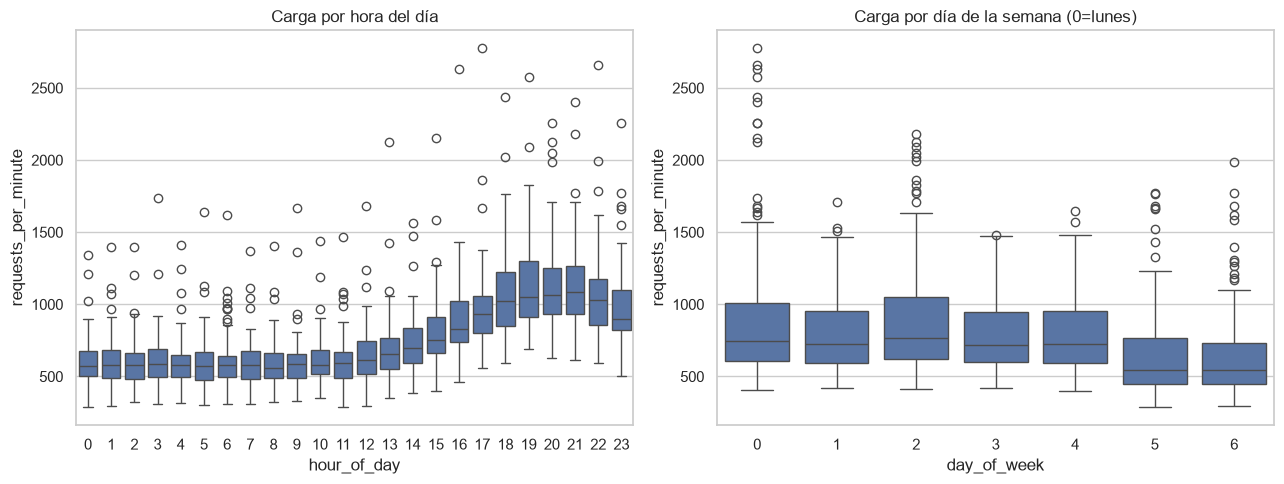

In [7]:
# Carga de la plataforma: estacionalidad diaria y semanal (multivariado temporal)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=load, x="hour_of_day", y="requests_per_minute", ax=axes[0])
axes[0].set_title("Carga por hora del día")
sns.boxplot(data=load, x="day_of_week", y="requests_per_minute", ax=axes[1])
axes[1].set_title("Carga por día de la semana (0=lunes)")
plt.tight_layout()
plt.show()


**Qué se observa:** la correlación más fuerte es entre `difficulty` y
`time_spent_seconds`; `connectivity_quality` correlaciona negativamente con el
tiempo (mejor señal, respuestas más rápidas). La carga de la plataforma
muestra picos claros en horas de la tarde-noche y mayor uso entre semana que
en fin de semana. **Qué significa:** confirma que la simulación introdujo
relaciones realistas (no ruido puro) y que existe estacionalidad diaria/semanal
aprovechable por el modelo de pronóstico S08 mediante variables de hora/día y
rezagos. **Decisión técnica:** conservar `hour_of_day`, `day_of_week` y las
variables de rezago (`requests_lag_*`) como features del pronóstico, tal como
se implementó en `03_pronostico_carga_plataforma.ipynb`.

## 5. Conclusiones del EDA

- Los datos simulados reproducen relaciones coherentes con reglas de negocio
  (dificultad, conectividad, compromiso del usuario) en vez de ruido aleatorio puro.
- Existen outliers y anomalías inyectadas de forma controlada y documentada,
  útiles para validar el detector no supervisado (U04) sin filtrarlos del resto
  de las tablas.
- Hay estacionalidad temporal clara en la carga de la plataforma, relevante
  para S08.
- El desbalance de clases en las tareas supervisadas es moderado y se atiende
  con las métricas y configuraciones de modelo adecuadas en cada notebook
  específico.
